# Ejercicios

Este cuaderno contiene ejercicios aplicados a problemas físicos reales.
Incluye raíces, derivadas numéricas, integración e interpretación física.

## Ejercicio 1: Tiempo de impacto (Bisección)
Modelo: 
\begin{align}
h(t)=50 - 5t - 4.9t^2
\end{align}

1. Implemente método de bisección.

2. Determine tiempo de impacto.

3. Analice convergencia.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def SigInt(f, inter):
    """
    Return the sign of the f(a)*f(b). In the case that this product is zero, return 0.
    """
    a, b = min(inter), max(inter)
    ya, yb = f(a), f(b)
    
    if (ya*yb<0):
        sig = -1 
    elif (ya*yb>0):
        sig = 1 
    else:
        sig = 0
    return sig

def Bis(f, inter, Nit, eps=1e-6):
    a, b = min(inter), max(inter)

    relMax = lambda pn1, pn: abs(pn1-pn)/abs(max([pn, pn1]))
    
    # p0 
    p0 = (a + b)/2
    sig = SigInt(f, [a, p0]) 
    if (sig>0):
        a = p0
    else:
        b = p0

    # pi
    for i in range(Nit):
        pi = (a + b)/2
        sig = SigInt(f, [a, pi])
        
        epsi = relMax(a, b)
        if abs(epsi)<=eps or sig==0.:
            root = pi
            break
        
        if (sig>0):
            a, p0 = pi, pi
        else:
            b, p0 = pi, pi
        
    if i==Nit-1:
        print('IMPORTANTE: la raiz encontrada no cumple el criterio de eps')
        root = pi
    return root

Text(0, 0.5, '$y$')

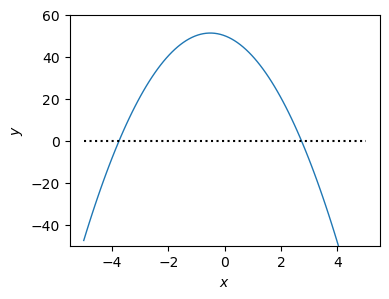

In [2]:
f = lambda t: 50 - 5*t - 4.9*t**2

inter = [-5, 5]
t = np.linspace(inter[0], inter[1], 100)

plt.figure(figsize=(4, 3), dpi=100)
plt.plot(t, f(t), ls='-', lw=1)
plt.hlines(y=0, xmin=-5, xmax=5, ls=':', color='k')
plt.ylim(-50, 60)
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")

In [3]:
f = lambda t: 50 - 5*t - 4.9*t**2

Ndiv_date = [5, 10, 25, 50, 100, 125, 150, 200]#np.linspace(20, 100, 10, dtype=int)
y_sol_date = []

inter = [0, 5]
for Ndiv in Ndiv_date:
    sol = Bis(f, inter, Ndiv, eps=1e-6)
    y_sol_date.append(sol)

IMPORTANTE: la raiz encontrada no cumple el criterio de eps
IMPORTANTE: la raiz encontrada no cumple el criterio de eps


Text(0, 0.5, 'root')

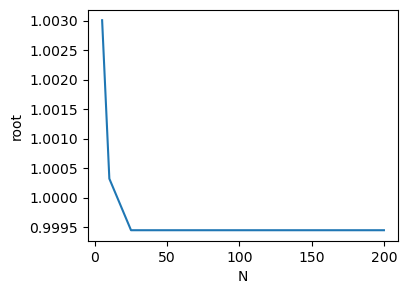

In [4]:
plt.figure(figsize=(4, 3), dpi=100)
plt.plot(Ndiv_date, y_sol_date/np.mean(y_sol_date))
plt.xlabel(r"N")
plt.ylabel(r"root")

In [5]:
print("La raiz es: ", np.mean(y_sol_date), '+/-' , np.std(y_sol_date))

La raiz es:  2.72617906332016 +/- 0.0031944678135781713


## Ejercicio 2: Método de Newton-Raphson
Use la misma función anterior.

1. Derive analíticamente y encuentre numéricamente la respuesta.

2. Compare iteraciones con bisección.

In [6]:
f = lambda t: 50 - 5*t - 4.9*t**2
df = lambda t: -5 - 9.8*t

In [7]:
def newton_raphson(f, df, x0, tol=1e-6, max_iter=100):
    """
    Método de Newton-Raphson para encontrar raíces.

    Parámetros:
    f        : función
    df       : derivada de la función
    x0       : valor inicial
    tol      : tolerancia
    max_iter : número máximo de iteraciones

    Retorna:
    Aproximación de la raíz
    """
    x = x0

    for i in range(max_iter):
        fx = f(x)
        dfx = df(x)

        if abs(dfx) < 1e-12:
            raise ValueError("La derivada es muy pequeña. El método falla.")

        x_new = x - fx / dfx

        if abs(x_new - x) < tol:
            return x_new

        x = x_new

    raise ValueError("No converge en el número máximo de iteraciones")

In [20]:
Ndiv_date = [5, 10, 25, 50, 100, 125, 150, 200]
y_sol_date_NR = []
y_sol_date = []

inter = [0, 5]
x0 = 2
for Ndiv in Ndiv_date:
    solNR = newton_raphson(f, df, x0, max_iter=Ndiv)
    sol = Bis(f, inter, Ndiv, eps=1e-6)
    y_sol_date.append(sol)
    y_sol_date_NR.append(solNR)

IMPORTANTE: la raiz encontrada no cumple el criterio de eps
IMPORTANTE: la raiz encontrada no cumple el criterio de eps


Text(0, 0.5, 'root')

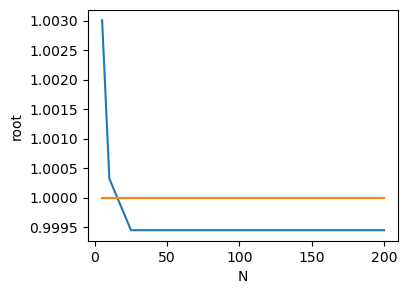

In [13]:
plt.figure(figsize=(4, 3), dpi=100)
plt.plot(Ndiv_date, y_sol_date/np.mean(y_sol_date))
plt.plot(Ndiv_date, y_sol_date_NR/np.mean(y_sol_date_NR))
plt.xlabel(r"N")
plt.ylabel(r"root")

In [ ]:
print("La raiz es: ", np.mean(y_sol_date_NR), '+/-' , np.std(y_sol_date_NR))

Raíz aproximada: 2.7246668334994872


## Ejercicio 3: Resorte no lineal

Considere una partícula de masa despreciable unida a un resorte cuya relación fuerza-deformación no es estrictamente lineal:

\begin{align}
F_r(x) = -k x - \alpha x^3
\end{align}

donde $k > 0$ es la constante elástica lineal, $\alpha > 0$ cuantifica la no linealidad y $x$ es la deformación respecto al equilibrio natural.

Suponga:

\begin{align}
k = 10 \ \text{N/m}, \quad \alpha = 0.5 \ \text{N/m}^3
\end{align}

Determine la deformación estática $x$ en equilibrio cuando la fuerza es de $20$ Newton.

1. Resolver $F(x)=20$ usando método de la secante.

2. Interpretar resultado físico.

In [ ]:
def F(x):
    return 10*x + 0.5*x**3 - 20


## Ejercicio 4: Derivada numérica (función analítica)

\begin{align}
x(t)=4t^3 - 3t^2 + 2t
\end{align}

1. Calcule velocidad con diferencia centrada.

2. Compare con derivada exacta.

In [ ]:
def x(t):
    return 4*t**3 - 3*t**2 + 2*t


## Ejercicio 5: Segunda derivada numérica
1. Estime aceleración usando fórmula centrada.
2. Analice error variando $h$.

In [ ]:

def segunda_derivada(f, t, h):
    return (f(t+h) - 2*f(t) + f(t-h))/h**2


## Ejercicio 6: Derivadas con datos experimentales
Calcule velocidad a partir de tabla dada.
Use diferencias hacia adelante y centrada.

In [ ]:

t = np.array([0.0,0.5,1.0,1.5,2.0])
x_data = np.array([0.00,1.20,4.90,10.80,19.60])
h = 0.5


## Ejercicio 7: Aceleración desde datos con ruido
Calcule derivada de velocidad experimental.
Discuta amplificación del ruido.

In [ ]:
v_data = np.array([2.1,2.5,3.7,6.2,9.8])


## Ejercicio 8: Integración - Regla del Trapecio
Calcule trabajo para $F(x)$ medido experimentalmente.

In [2]:
# data
x_force = np.array([0, 1, 2, 3, 4])
F_data = np.array([0, 3, 8, 15, 24])

def trapecio(f, h):
    return h*(0.5*f[0] + sum(f[1:-1]) + 0.5*f[-1])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print(f"El trabajo de {x_force[0]} a {x_force[-1]} es {trapecio(F_data, 1)}")

El trabajo de 0 a 4 es 38.0


In [9]:
# Alternativa
from scipy import interpolate

f = interpolate.interp1d(x_force, F_data, kind="quadratic")

def ftrapecio(f, a, b, n):
    h = (b-a)/n
    x = np.linspace(a, b, n+1)
    return h*(0.5*f(a) + sum(f(x[1:-1])) + 0.5*f(b))

print(f"El trabajo de {x_force[0]} a {x_force[-1]} es {ftrapecio(f, x_force[0], x_force[-1], n=100)}")

El trabajo de 0 a 4 es 37.3344


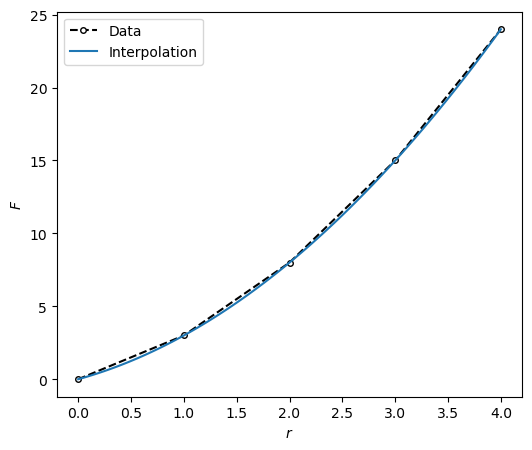

In [22]:
x = np.linspace(x_force[0], x_force[-1], 100)

plt.figure(figsize=(6, 5), dpi=100)
plt.plot(x_force, F_data, ls='--', marker='o', markersize=4, c='k', mfc='white', label='Data')
plt.plot(x, f(x), '-', label='Interpolation')
plt.xlabel(r"$r$")
plt.ylabel(r"$F$")
plt.legend()


## Ejercicio 9: Regla de Simpson
Implemente Simpson compuesto.
Compare con trapecio y analice orden de error.

In [ ]:
def simpson(f, a, b, n):
    h = (b-a)/n
    s = f(a) + f(b)
    for i in range(1,n):
        coef = 4 if i%2!=0 else 2
        s += coef * f(a+i*h)
    return s*h/3


# Ejercicio 10: Trabajo con fuerza polinómica

Una fuerza variable actúa sobre una partícula:

\begin{align}
F(x) = 6x^2 - 4x + 1
\end{align}

Calcular el trabajo realizado entre $x=0$ y $x=3$.

Método:
1.	Plantee la integral que representa el trabajo.

2.	Calcule el valor exacto analíticamente.
3.	Implemente:

    •	Regla del Trapecio compuesta
    
	•	Regla de Simpson compuesta

4.	Use $n = 4, 8, 16, 32$.
5.	Grafique error vs $n$.

6.	Determine el orden de convergencia experimental.

In [ ]:
import numpy as np

def F(x):
    return 6*x**2 - 4*x + 1

def trapecio(f, a, b, n):
    h = (b-a)/n
    x = np.linspace(a, b, n+1)
    return h*(0.5*f(a) + sum(f(x[1:-1])) + 0.5*f(b))

def simpson(f, a, b, n):
    h = (b-a)/n
    x = np.linspace(a,b,n+1)
    s = f(a) + f(b)
    for i in range(1,n):
        coef = 4 if i%2!=0 else 2
        s += coef*f(x[i])
    return s*h/3

# Ejercicio 11:  Energía potencial gravitatoria efectiva

Una partícula se mueve en un potencial:
\begin{align}
U(r) = -\frac{GMm}{r} + \frac{L^2}{2mr^2}
\end{align}

Considere: $G=1, M=10, m=1, L=4$.

1. Calcule la energía potencial promedio entre $r=2$ y $r=6$.

Recordar:

\begin{align}
\bar{U} = \frac{1}{b-a}\int_a^b U(r)dr
\end{align}


2. Evalúe numéricamente con:
	•	Trapecio
	•	Simpson

3.	Analice el comportamiento cerca de $r=2$.

4.	¿Qué ocurre si el intervalo se acerca a $r=0$?

## Ejercicio 12: Problema integrador

\begin{align}
v(t)=20e^{-0.3t}
\end{align}

1. Encuentre tiempo cuando $v=5$.

2. Calcule aceleración numérica.

3. Integre para obtener desplazamiento.

4. Compare con solución analítica.

In [ ]:

def v(t):
    return 20*np.exp(-0.3*t)


# Ejercicio 13 — Energía disipada por fricción viscosa

Una fuerza viscosa depende de la velocidad:

\begin{align}
F(v) = -\gamma v^3
\end{align}

con $\gamma = 0.2$.

Si la velocidad cambia desde $v=0$ hasta $v=5$, calcular el trabajo disipado.

1.	Plantee la integral.
2.	Calcule el valor exacto.
3.	Compare con integración numérica.

4.	Analice cómo cambia el error al duplicar n.

# Ejercicio 14 — Probabilidad en distribución Gaussiana

Considere:

\begin{align}
f(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}
\end{align}

Calcular la probabilidad: $P(-1 \le x \le 1)$

1.	Evalúe usando Simpson.

3.	Analice por qué el trapecio converge más lento.

4.	Estime el error relativo.

# Ejercicio 15 — Flujo de calor dependiente del tiempo

El flujo térmico es:

\begin{align}
q(t) = 10e^{-0.5t}\sin(2t)
\end{align}

Calcular el calor total transferido entre $t=0$ y $t=5$.

1.	Grafique la función.

2.	Evalúe con Simpson.

3.	Compare con trapecio.

4.	Analice qué ocurre si la función es altamente oscilatoria.

# Ejercicio 16 — Carga total en una distribución no uniforme

Densidad lineal:

\begin{align}
\lambda(x) = 5 + 2\sin(x)
\end{align}

Calcular la carga total en el intervalo $[0,\pi]$.

1.	Resolver analíticamente.

2.	Resolver numéricamente.

3.	Calcular error absoluto.

4.	Verificar orden de convergencia.


# Ejercicio 17 — Energía en un oscilador no lineal

La energía potencial es:

\begin{align}
U(x) = \frac{1}{2}kx^2 + \frac{\beta}{4}x^4
\end{align}

Con $k=5, \beta=1$

1. Calcular el trabajo necesario para llevar la partícula desde $x=0$ hasta $x=2$.

2.	Plantee la integral.
3.	Compare métodos.
4.	Analice cómo influye el término no lineal.